Data Preprocessing

First we import all the necessary libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split    
from sklearn.svm import SVC

pd.set_option('display.max_columns', None)

This drops the columns we agreed on that have a significant enough amount of missing values to remove them.

The columns that are printed are the features that will be used to create the decision tree.

In [2]:
df = pd.read_csv('../Data/raw_data.csv', sep=';')

columns_to_drop = ['stem-root','veil-type', 'veil-color',  'stem-surface', 'spore-print-color']
df = df.drop(columns=columns_to_drop)
df.columns

Index(['class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-color', 'has-ring', 'ring-type',
       'habitat', 'season'],
      dtype='object')

In [3]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline


class KNNCategoricalImputer(BaseEstimator, TransformerMixin):
    """
    Supervised KNN imputer for one or more categorical columns.

    - Assumes input X is a pandas DataFrame with original columns.
    - For each target column:
        * uses all other columns that have no missing values as predictors
        * does its own StandardScaler + OneHotEncoder internally
    """

    def __init__(self, target_cols, num_cols=None, n_neighbors=5, weights="distance"):
        # allow a single string or a list
        if isinstance(target_cols, str):
            target_cols = [target_cols]

        self.target_cols = target_cols
        self.num_cols = num_cols   # list of numeric columns to scale 
        self.n_neighbors = n_neighbors
        self.weights = weights

    def fit(self, X, y=None):
        df = X.copy()

        self.knn_models_ = {}
        self.feature_cols_ = {}

        for col in self.target_cols:
            # rows where the target is known
            mask = df[col].notna()

            # trainable columns: all except the target, and with no missing values on these rows
            _X_train_tmp = df.loc[mask].drop(columns=[col])
            train_columns = _X_train_tmp.columns[
                _X_train_tmp.isnull().sum() == 0
            ].tolist()

            X_train = df.loc[mask, train_columns]
            y_train = df.loc[mask, col]

            # numeric + categorical columns for THIS target
            if self.num_cols is None:
                # if not provided, infer numeric from dtypes
                num_cols = X_train.select_dtypes(include="number").columns.tolist()
            else:
                # keep only those num_cols that are actually in train_columns
                num_cols = [c for c in self.num_cols if c in train_columns]

            cat_cols = [c for c in train_columns if c not in num_cols + [col]]

            # preprocessor for KNN
            pre = ColumnTransformer(
                transformers=[
                    ("num", StandardScaler(), num_cols),
                    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
                ]
            )

            # KNN classifier pipeline
            clf = Pipeline(
                steps=[
                    ("pre", pre),
                    (
                        "knn",
                        KNeighborsClassifier(
                            n_neighbors=self.n_neighbors, weights=self.weights
                        ),
                    ),
                ]
            )

            # fit KNN for this target column
            clf.fit(X_train, y_train)

            # store model and the columns it expects
            self.knn_models_[col] = clf
            self.feature_cols_[col] = train_columns

        return self

    def transform(self, X):
        df = X.copy()

        for col in self.target_cols:
            mask_missing = df[col].isna()

            if mask_missing.any():
                feats = self.feature_cols_[col]
                X_missing = df.loc[mask_missing, feats]
                df.loc[mask_missing, col] = self.knn_models_[col].predict(X_missing)

        return df

In [4]:
from sklearn import set_config
from sklearn.preprocessing import LabelEncoder
set_config(transform_output="pandas") 


x = df.drop(columns='class')
y = df['class']

# label encode y 

le = LabelEncoder()
y = le.fit_transform(y)

numeric_features = x.select_dtypes(include='float64').columns.to_list()
categorical_features = x.select_dtypes(include='object').columns.to_list()

# Columns to impute
features_to_impute = ['cap-surface', 'gill-attachment', 'gill-spacing', 'ring-type']

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False  # 
)


knn_imputer = KNNCategoricalImputer(
    target_cols=features_to_impute,
    num_cols=numeric_features
)


column_trans = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)


preprocess = Pipeline(steps=[
    ('knn_imputer', knn_imputer),      # impute missing values using KNN 
    ('column_transformer', column_trans)  
])


x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)


preprocess.fit(x_train)

x_train = preprocess.transform(x_train)
x_test = preprocess.transform(x_test)

x_train


,cap-diameter,stem-height,stem-width,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_d,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,cap-surface_l,cap-surface_s,cap-surface_t,cap-surface_w,cap-surface_y,cap-color_b,cap-color_e,cap-color_g,cap-color_k,cap-color_l,cap-color_n,cap-color_o,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,does-bruise-or-bleed_f,does-bruise-or-bleed_t,gill-attachment_a,gill-attachment_d,gill-attachment_e,gill-attachment_f,gill-attachment_p,gill-attachment_s,gill-attachment_x,gill-spacing_c,gill-spacing_d,gill-spacing_f,gill-color_b,gill-color_e,gill-color_f,gill-color_g,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stem-color_b,stem-color_e,stem-color_f,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y,has-ring_f,has-ring_t,ring-type_e,ring-type_f,ring-type_g,ring-type_l,ring-type_m,ring-type_p,ring-type_r,ring-type_z,habitat_d,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_a,season_s,season_u,season_w
36219,-0.195867,-0.104756,-0.639647,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
54188,0.039043,-0.801696,-0.439222,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1609,0.313735,1.253535,0.218893,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
20481,-0.616430,-0.736450,-0.574833,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
20546,-0.654319,-0.819490,-0.613722,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28217,0.012521,-0.629685,0.036415,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
51211,-0.455404,0.013872,-0.044353,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [5]:
y_train

array([0, 1, 1, ..., 1, 1, 0], shape=(48855,))

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

Here is where a decision tree is trained with no parameters other than setting the criterion to entropy and putting a set random state for reproducibility.

In [7]:
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(x_train, y_train)


,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Here the classifier predicts the class for each sample in the test set, and the accuracy is calculated using this and the true class of each of the test set samples.

The confusion matrix gives us the data on the number of true positive and negatives predicted versus the false positives and negatives that were predicted.

In [8]:

y_pred = clf.predict(x_test)
y_pred_train = clf.predict(x_train) 

test_accuracy = accuracy_score(y_test, y_pred)
train_accuracy = accuracy_score(y_train, y_pred_train)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Training Accuracy: 1.0000
Test Accuracy: 0.9980

Classification Report:
              precision    recall  f1-score   support

           0     0.9980    0.9974    0.9977      5436
           1     0.9979    0.9984    0.9982      6778

    accuracy                         0.9980     12214
   macro avg     0.9980    0.9979    0.9979     12214
weighted avg     0.9980    0.9980    0.9980     12214


Confusion Matrix:
[[5422   14]
 [  11 6767]]


Here we can analyze the graph of the importance each feature has in the prediction of each class.

Top 10 Most Important Features:
              feature  importance
2          stem-width    0.155425
1         stem-height    0.092890
0        cap-diameter    0.050236
68       stem-color_w    0.042707
41  gill-attachment_x    0.041452
55       gill-color_w    0.040322
43     gill-spacing_d    0.038905
3         cap-shape_b    0.025978
22        cap-color_e    0.022186
6         cap-shape_o    0.020107


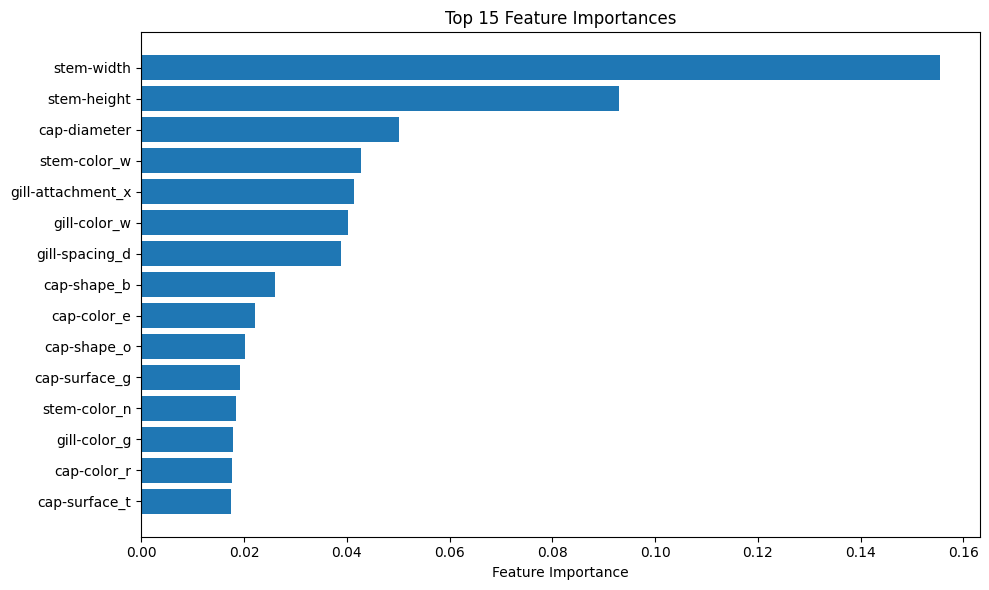

In [9]:
# Step 5: Analyze feature importance
feature_importance = pd.DataFrame({
    'feature': x_train.columns,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Now that we see the results for just a basic decision tree trained on the data with no parameters like maximum depth, minimum samples for split, minimum samples per leaf 

In [10]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['entropy', 'gini']
}

# Create base model
dt = DecisionTreeClassifier(random_state=42)

# GridSearchCV with cross-validation
grid_search = GridSearchCV(
    dt, 
    param_grid, 
    cv=5, 
    scoring='f1',  # or 'roc_auc'
    n_jobs=-1, 
    verbose=1
)

# Fit on training data
grid_search.fit(x_train, y_train)

# Best parameters
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Use best model
best_clf = grid_search.best_estimator_

Fitting 5 folds for each of 128 candidates, totalling 640 fits
Best parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best cross-validation score: 0.9950564799977368


In [11]:
print(f"Tree depth: {best_clf.tree_.max_depth}")
print(f"Number of nodes: {best_clf.tree_.node_count}")

Tree depth: 20
Number of nodes: 663


In [12]:
best_clf.fit(x_train, y_train)

best_y_pred = best_clf.predict(x_test)
best_y_pred_train = best_clf.predict(x_train) 

best_test_accuracy = accuracy_score(y_test, best_y_pred)
best_train_accuracy = accuracy_score(y_train, best_y_pred_train)

print(f"Training Accuracy: {best_train_accuracy:.4f}")
print(f"Test Accuracy: {best_test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, best_y_pred, digits=4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_y_pred))

Training Accuracy: 0.9994
Test Accuracy: 0.9974

Classification Report:
              precision    recall  f1-score   support

           0     0.9976    0.9965    0.9971      5436
           1     0.9972    0.9981    0.9976      6778

    accuracy                         0.9974     12214
   macro avg     0.9974    0.9973    0.9973     12214
weighted avg     0.9974    0.9974    0.9974     12214


Confusion Matrix:
[[5417   19]
 [  13 6765]]


In [13]:
print("Test accuracy of basic decision tree: ", test_accuracy)
print("Training accuracy of basic decision tree: ", train_accuracy)
print("difference: ", train_accuracy - test_accuracy)

print("Test accuracy of best decision tree: ", best_test_accuracy)
print("Training accuracy of best decision tree: ", best_train_accuracy)
print("difference: ", best_train_accuracy - best_test_accuracy)

Test accuracy of basic decision tree:  0.9979531684951695
Training accuracy of basic decision tree:  1.0
difference:  0.0020468315048305374
Test accuracy of best decision tree:  0.9973800556738169
Training accuracy of best decision tree:  0.9994268754477535
difference:  0.0020468197739366145


In [14]:
from sklearn.metrics import f1_score


test_f1 = f1_score(y_test, y_pred)
train_f1 = f1_score(y_train, y_pred_train)

best_test_f1 = f1_score(y_test, best_y_pred)
best_train_f1 = f1_score(y_train, best_y_pred_train)

print("Test f1 of basic decision tree: ", test_f1)
print("Training f1 of basic decision tree: ", train_f1)
print("difference: ", train_f1 - test_f1)

print("Test f1 of best decision tree: ", best_test_f1)
print("Training f1 of best decision tree: ", best_train_f1)
print("difference: ", best_train_f1 - best_test_f1)





Test f1 of basic decision tree:  0.9981562062098975
Training f1 of basic decision tree:  1.0
difference:  0.001843793790102466
Test f1 of best decision tree:  0.9976404660079634
Training f1 of best decision tree:  0.9994835663432808
difference:  0.001843100335317427


So according to our grid search a more optimal, simplified decision tree uses the parameters:

{'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5}

This will be our final tree that we analyze and visualize.

Summary of Results

To show the results of training the decision tree on this data, we can show the classification report, accuracy, and confusion matrix using the predictions of this model.

Then, we want to create a ROC curve graph to be able to compare this model to our other different types of models.

In [15]:
best_y_pred_proba = best_clf.predict_proba(x_test)
best_y_pred_proba_positive = best_y_pred_proba[:, 1]

best_y_pred_proba_positive

array([0.       , 1.       , 0.7173913, ..., 1.       , 0.       ,
       0.       ], shape=(12214,))

In [16]:
best_y_pred = best_clf.predict(x_test)

best_y_pred

array([0, 1, 1, ..., 1, 0, 0], shape=(12214,))

In [17]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
report = classification_report(y_test, best_y_pred, digits=4)
print(report)

              precision    recall  f1-score   support

           0     0.9976    0.9965    0.9971      5436
           1     0.9972    0.9981    0.9976      6778

    accuracy                         0.9974     12214
   macro avg     0.9974    0.9973    0.9973     12214
weighted avg     0.9974    0.9974    0.9974     12214



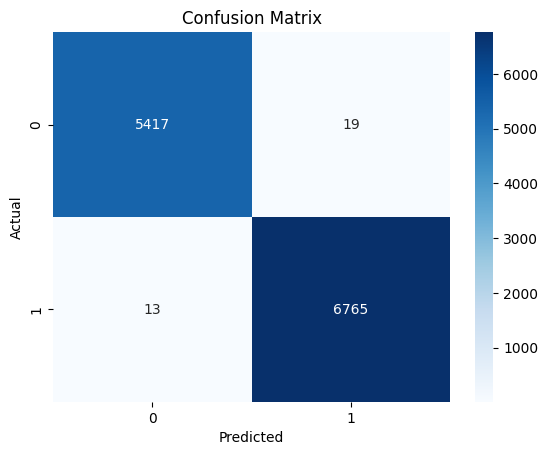

In [18]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, best_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

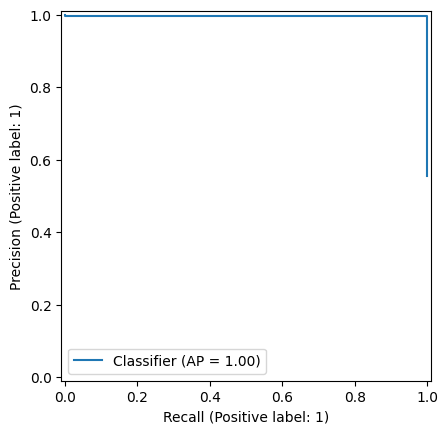

In [19]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test, best_y_pred_proba_positive)


In [20]:
from sklearn.metrics import roc_curve, roc_auc_score



fpr, tpr, thresholds = roc_curve(y_test, best_y_pred_proba_positive)

auc_score = roc_auc_score(y_test, best_y_pred_proba_positive)

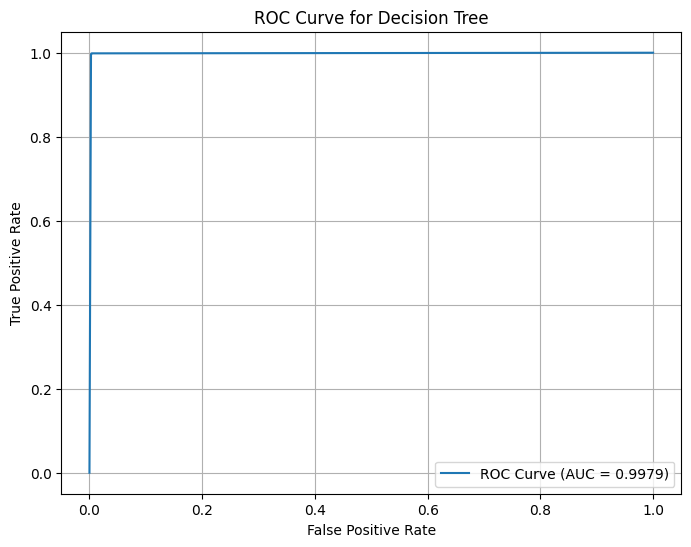

In [21]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Decision Tree')
plt.legend()
plt.grid(True)
plt.show()

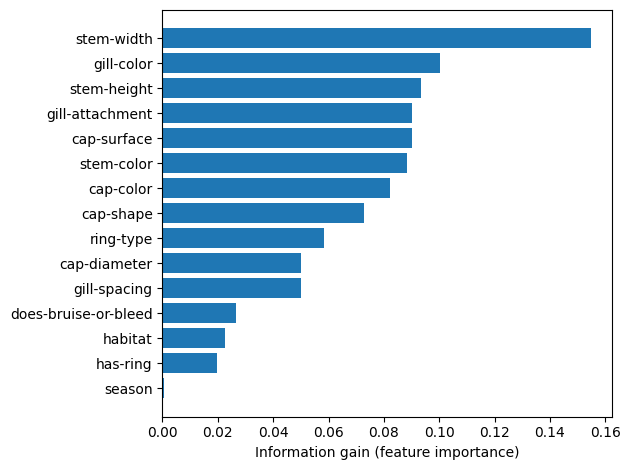

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# feature names AFTER preprocessing (one-hot columns included)
feature_names = x_train.columns
importances = best_clf.feature_importances_

# Put into a DataFrame
imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# For one-hot columns, sklearn names them like "cap-shape_flat", "cap-shape_convex", ...
# So we take everything before the first "_" as the original feature name
imp_df['orig_feature'] = imp_df['feature'].str.split('_', n=1).str[0]

# Sum importances over dummies belonging to the same original feature
agg = (
    imp_df
    .groupby('orig_feature', as_index=False)['importance']
    .sum()
)

# Sort for nicer plotting
agg = agg.sort_values('importance')

# Plot one bar per original feature
plt.barh(agg['orig_feature'], agg['importance'])
plt.xlabel("Information gain (feature importance)")
plt.tight_layout()
plt.show()